# Example
using resources from https://huggingface.co/docs/transformers/model_doc/wav2vec2 ingest wav files, embed them and display results

In [64]:
import os
os.environ['CUDA_VISIBLE_DEVICES']="1"
from umap import UMAP
from tqdm import tqdm
import matplotlib.pyplot as plt
import librosa
from glob import glob
import torch
import numpy as np
import random
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC, Wav2Vec2Model
 

fnames= glob("hammer_wavs/clean/train/*") # raw or hammer 
random.shuffle(fnames)
assert len(fnames) > 0
len(fnames)

85589

In [65]:

#load model and processor
mname = "../transformers/examples/pytorch/speech-pretraining/hammer2vec2-pretrained-demo"
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-large-960h")
#model = Wav2Vec2ForCTC.from_pretrained("facebook/wav2vec2-large-960h")
model = Wav2Vec2Model.from_pretrained(mname)
 

Some weights of the model checkpoint at ../transformers/examples/pytorch/speech-pretraining/hammer2vec2-pretrained-demo were not used when initializing Wav2Vec2Model: ['quantizer.codevectors', 'quantizer.weight_proj.bias', 'project_hid.weight', 'project_hid.bias', 'project_q.bias', 'project_q.weight', 'quantizer.weight_proj.weight']
- This IS expected if you are initializing Wav2Vec2Model from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2Model from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [66]:
# retrieve logits
x_train=[]

N = 2000
for f in tqdm(fnames[:N]):
    try:
        x, sr = librosa.load(f, sr=16000) 
        input_values = processor(x, sampling_rate=16000, return_tensors="pt", padding="longest").input_values  # Batch size 1
        outputs = model(input_values, output_hidden_states=True)
        #x_train.append(np.squeeze(outputs['hidden_states'][0].detach().numpy()))
        x_train.append(np.squeeze(outputs['last_hidden_state'][0][0].detach().numpy()))
    except:
        pass


100%|███████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [1:46:27<00:00,  3.19s/it]


In [67]:
x_train = np.vstack([x for x in x_train])
mapper = UMAP().fit_transform(x_train)
print(mapper.shape)

(2000, 2)


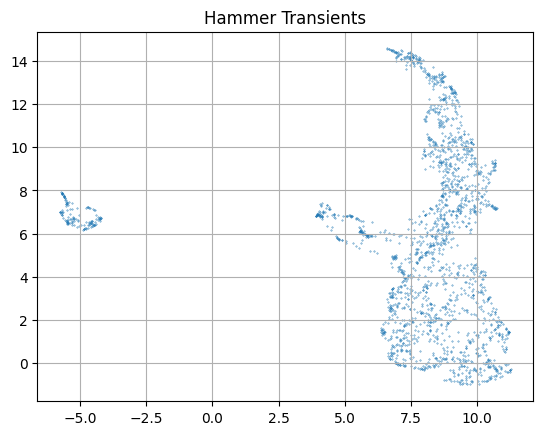

In [68]:
plt.scatter(mapper[:,0], mapper[:,1], s=.1)
plt.title("Hammer Transients")
plt.grid()
plt.plot()

In [95]:
from IPython.display import Audio
from scipy.spatial import KDTree
import random

tree = KDTree(mapper)

points = [(5,7), (-5,7)]
idx = tree.query_ball_point(points[0],.8, return_sorted=True)
print(idx)
f = fnames[random.choice(idx)]
print(f)
Audio(f, rate=16000, autoplay=True)



[159, 211, 233, 259, 271, 389, 499, 602, 670, 728, 730, 771, 801, 1078, 1112, 1118, 1137, 1147, 1177, 1200, 1274, 1357, 1379, 1513, 1564, 1605, 1635, 1751, 1761, 1778, 1811, 1841, 1858, 1887, 1891, 1959, 1986]
raw_wavs/clean/train/73fbc8a2-a768-415d-ada0-6b24f424416e.wav


9
10
18
29
48
88
97
137
146
160


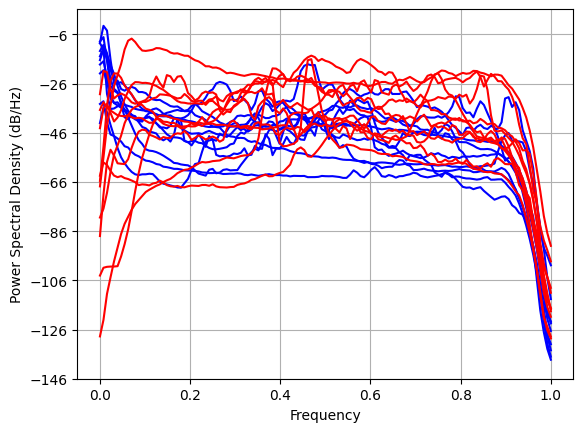

In [96]:
idx = tree.query_ball_point(points[0],.6, return_sorted=True)
for i in idx[:10]:
    x, sr = librosa.load(fnames[i], sr=16000)
    plt.psd(x, c='b')
    
idx = tree.query_ball_point(points[1],1, return_sorted=True)
for i in idx[:10]:
    print(i)
    x, sr = librosa.load(fnames[i], sr=16000)
    plt.psd(x, c='r')

ref:  https://discuss.huggingface.co/t/wav2vec2-hidden-states/32654
